# Titanic Dataset — EDA and Data Story

This notebook performs the profiling, cleaning, exploratory data analysis,
and visualization tasks for the Titanic dataset.

The raw Titanic dataset is loaded once using Seaborn's built-in dataset
loader and is saved as `titanic.csv` as an offline fallback.

Step 1 — Import libraries and load dataset

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")

df.to_csv('titanic.csv',index=False)

print("Dataset loaded and saved successfully.")

Dataset loaded and saved successfully.


In [3]:
print(df.shape)

(891, 15)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Step 2 — Missing-value handling

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_percentage"] > 0
]

display(missing_summary)

,missing_count,missing_percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


The Titanic dataset was loaded using Seaborn's built-in titanic dataset loader. The dataset was profiled using info(), describe(), and shape to understand its structure, data types, dimensions, and numerical statistics. Missing-value percentages were calculated for all columns containing missing values. The raw dataset was also saved as titanic.csv to provide an offline fallback for subsequent analysis.

In [8]:
df["age"] = df["age"].fillna(df["age"].median())

In [9]:
df = df.dropna(subset =['embarked']) 

In [10]:
df["deck"] = df["deck"].astype("object").fillna("Unknown")

In [12]:
df = df.dropna(subset=['embark_town'])

In [14]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

Missing Value Handling: The age column had 19.8653% missing values, which falls within the 5%–30% range, so missing ages were imputed using the median. embarked and embark_town had only 0.2245% missing values each, which is below the 5% threshold, so the corresponding rows were dropped. deck had 77.2166% missing values, making conventional imputation unreliable; therefore, missing values were retained as a separate "Unknown" category rather than replacing them with an arbitrary deck value.

Step 3 — Univariate analysis

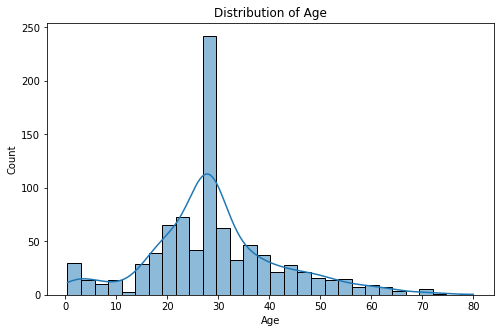

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

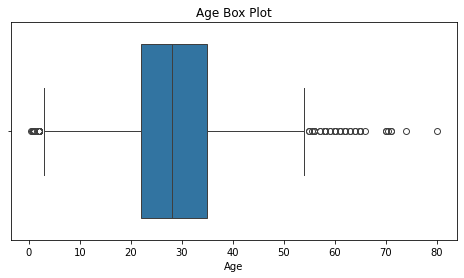

In [16]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["age"])

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.show()

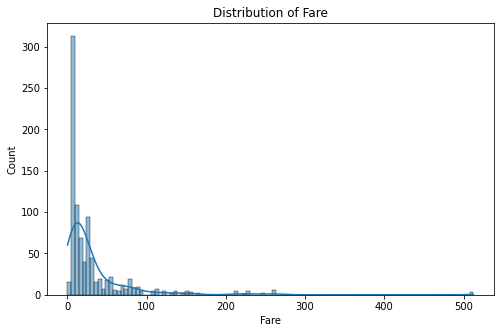

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

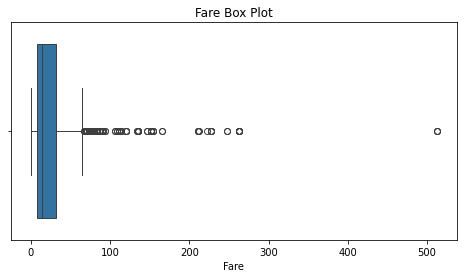

In [18]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["fare"])

plt.title("Fare Box Plot")
plt.xlabel("Fare")

plt.show()

In [19]:
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return q1, q3, iqr, lower_bound, upper_bound, outliers

In [20]:
for column in ["age", "fare"]:
    q1, q3, iqr, lower, upper, outliers = find_iqr_outliers(df[column])

    print(f"\n{column.upper()}")
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))


AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of outliers: 114


In [21]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode.tolist())

Mean: 32.09668087739032
Median: 14.4542
Mode: [8.05]


In [22]:
fare_skewness = df['fare'].skew()

print("Fare skewness:", fare_skewness)

Fare skewness: 4.801440211044194


### Fare Distribution

The mean, median, and mode of `fare` were calculated to understand
the central tendency of the distribution. The ordering of these
values, together with the histogram and skewness value, is used to
determine whether the fare distribution is right-skewed, left-skewed,
or approximately symmetric.

The box plot also shows the presence of high-value fare observations.

fare is strongly right-skewed because of the relatively small number of very high fares.

Step 4 — Bivariate analysis

In [23]:
female = df[df["sex"] == "female"]
male = df[df["sex"] == "male"]

female_survival = female["survived"].mean()
male_survival = male["survived"].mean()

print("Female survival rate:", female_survival)
print("Male survival rate:", male_survival)

Female survival rate: 0.7403846153846154
Male survival rate: 0.18890814558058924


In [24]:
first_class = df[df["pclass"] == 1]
second_class = df[df["pclass"] == 2]
third_class = df[df["pclass"] == 3]

print("1st class:", first_class["survived"].mean())
print("2nd class:", second_class["survived"].mean())
print("3rd class:", third_class["survived"].mean())

1st class: 0.6261682242990654
2nd class: 0.47282608695652173
3rd class: 0.24236252545824846


In [25]:
female_first = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

female_second = df[
    (df["sex"] == "female") &
    (df["pclass"] == 2)
]

female_third = df[
    (df["sex"] == "female") &
    (df["pclass"] == 3)
]

male_first = df[
    (df["sex"] == "male") &
    (df["pclass"] == 1)
]

male_second = df[
    (df["sex"] == "male") &
    (df["pclass"] == 2)
]

male_third = df[
    (df["sex"] == "male") &
    (df["pclass"] == 3)
]

In [26]:
sex_class_survival = (
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .reset_index(name="survival_rate")
)

display(sex_class_survival)

,sex,pclass,survival_rate
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


In [27]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


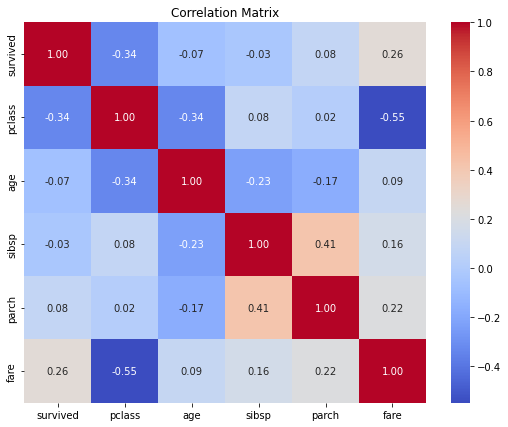

In [28]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [29]:
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack()

strongest_two = (
    corr_pairs
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Two strongest correlations:")
display(strongest_two)

Two strongest correlations:


pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64

Step 5 — Multivariate data story

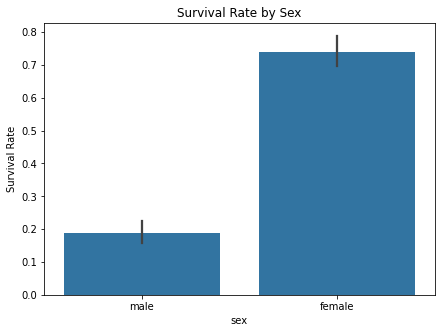

In [30]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

### Interpretation

The survival rate differs substantially between male and female passengers. Female passengers have a higher observed survival rate than male passengers in this dataset. This indicates that sex is an important variable for understanding the survival outcome.

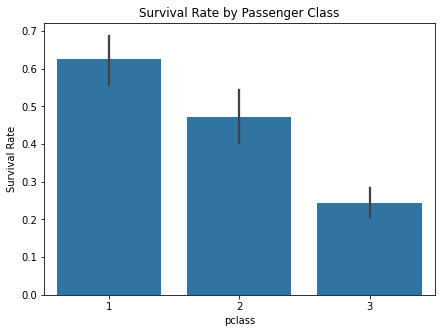

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

### Interpretation

Survival rates vary across passenger classes. The survival rate generally decreases as passenger class moves from first class toward third class. This suggests that passenger class is associated with different survival outcomes.

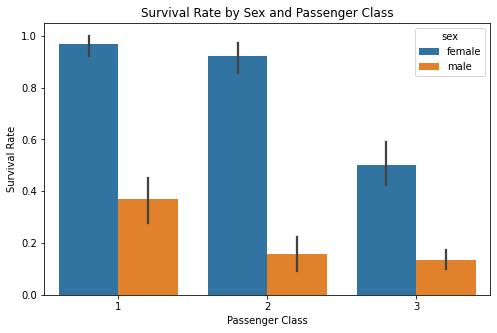

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

### Interpretation

Combining sex and passenger class reveals differences that are not visible when looking at either variable alone. Survival rates vary
between males and females within each passenger class. This provides a more detailed view of how multiple passenger characteristics relate
to survival.

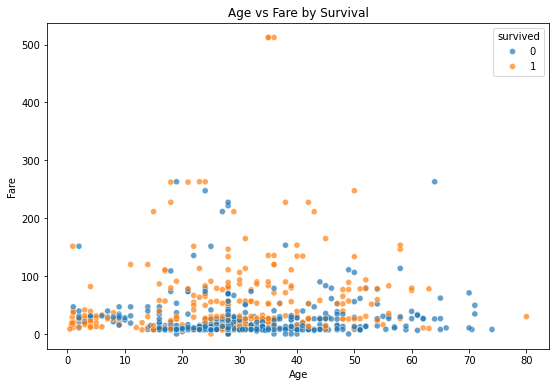

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    hue='survived',
    alpha=0.7
)

plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

### Interpretation

The scatter plot shows the relationship between passenger age and fare while distinguishing passengers by survival outcome. Fare values
are concentrated at lower levels, with some high-fare observations appearing as outliers. The plot also shows that survival cannot be
explained by age or fare alone, supporting the need for a multivariate model.

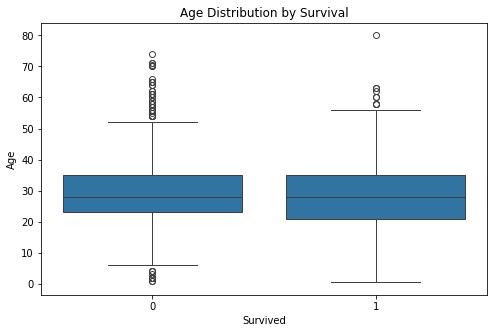

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='survived',
    y='age'
)

plt.title('Age Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Age')

plt.show()

### Interpretation

The age distributions of survivors and non-survivors overlap substantially, although their central tendencies differ. This suggests
that age may contribute to the prediction of survival but is not sufficient by itself to explain the outcome.

Step 6 — Standardize age and fare

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

df_eda_scaled = df.copy()

df_eda_scaled[["age", "fare"]] = scaler.fit_transform(
    df_eda_scaled[["age", "fare"]]
)

In [37]:
print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504


In [38]:
print("\nAfter standardization:")
print(df_eda_scaled[["age", "fare"]].agg(["mean", "std"]))


After standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


In [42]:
df.to_csv("titanic_cleaned.csv", index=False)